# Where we left off Tuesday

Variance of dice rolls

## Variance
- **How far do you expect $X$ to be from its expectation**?
- The **variance** of $X$ is the expected value of the squared deviations $(X-\mathbb{E}[X])^2$ of $X$ from its expected value:
$$
\mathbb{V}[X] = \mathbb{E}[(X-\mathbb{E}[X])^2] = \sum_{\ell =1}^L p_\ell (x_\ell - \mathbb{E}[X])^2
$$
- This measure how dispersed $X$ is around its expectation
- Why standard deviation squared?

## Dice
- Let's roll two six-sided dice
- There are 36 possible outcomes:
$$
\begin{array}{cccccc}
(1,1) & (1,2) & (1,3) & (1,4) & (1,5) & (1,6) \\
(2,1) & (2,2) & (2,3) & (2,4) & (2,5) & (2,6) \\
(3,1) & (3,2) & (3,3) & (3,4) & (3,5) & (3,6) \\
(4,1) & (4,2) & (4,3) & (4,4) & (4,5) & (4,6) \\
(5,1) & (5,2) & (5,3) & (5,4) & (5,5) & (5,6) \\
(6,1) & (6,2) & (6,3) & (6,4) & (6,5) & (6,6) \\
\end{array}
$$

## Example
- What is the variance of a single die roll?
- What is the variance of rolling two dice, and summing?
- What is the variance of the minimum of two die? The maximum?

In [2]:
import numpy as np

die_outcomes = np.array([1,2,3,4,5,6])

# outcomes of two dice summed
two_dice = die_outcomes+die_outcomes.reshape(-1,1)



Expectation and variance of 1 die roll

In [3]:
exp_x = np.sum(die_outcomes * (1/len(die_outcomes)))
print(exp_x)
var_x = np.sum((die_outcomes - exp_x)**2 * (1/len(die_outcomes)))
print(var_x)

3.5
2.9166666666666665


Expectation and variance of two dice summed

In [4]:
exp_2_x = 2*exp_x
var_2_x = np.sum((two_dice - 2*exp_x)**2 * (1/len(die_outcomes)**2))
print(exp_2_x)
print(var_2_x)

7.0
5.833333333333334


Expectation and variance of the minimum of two dice summed



In [5]:
# for each outcome, how often does the minimum = 1? 2? etc?

min_outcomes = np.minimum(die_outcomes, die_outcomes.reshape(-1,1))
print(min_outcomes)



[[1 1 1 1 1 1]
 [1 2 2 2 2 2]
 [1 2 3 3 3 3]
 [1 2 3 4 4 4]
 [1 2 3 4 5 5]
 [1 2 3 4 5 6]]


In [6]:
exp_min_x = np.sum(min_outcomes * (1/len(die_outcomes)**2))
print(exp_min_x)

2.5277777777777777


In [7]:
# variance of the minimum
var_min_x = np.sum((min_outcomes - exp_min_x)**2 * (1/len(die_outcomes)**2))
print(var_min_x)

1.9714506172839505


In [8]:
# for each outcome, how often does the maximum = 1? 2? etc?

max_outcomes = np.maximum(die_outcomes, die_outcomes.reshape(-1,1))
print(max_outcomes)

[[1 2 3 4 5 6]
 [2 2 3 4 5 6]
 [3 3 3 4 5 6]
 [4 4 4 4 5 6]
 [5 5 5 5 5 6]
 [6 6 6 6 6 6]]


In [9]:
exp_max_x = np.sum(max_outcomes * (1/len(die_outcomes)**2))
print(exp_max_x)

4.472222222222222


In [10]:
# variance of the maximum
var_max_x = np.sum((max_outcomes - exp_max_x)**2 * (1/len(die_outcomes)**2))
print(var_max_x)

1.9714506172839505


## Probability Mass Functions
- Once we've picked a random variable and make the assignment of outcomes to numbers, we can ask, "What is the probability that $X$ takes a given numeric value?"

- For each value $x$ that $X$ can take, the **probability mass function** gives $p[ X = x ]$
- In detail: $p[ X = x ] = p[ \{ \text{ every } s \text{ in } \mathcal{S} \text{ such that } X(s) = x \text{ }\}]$
- Notice that if $X$ only takes values $x_1, x_2, ..., x_L$, then $\sum_{\ell = 1}^L p[X=x_\ell] =\sum_{\ell = 1}^L p_\ell = 1$

## The PMF of a single die roll

p(1) = p(2) = p(3) = p(4) = p(5) = p(6) = 1/6,      Σₖ p(k) = 1



<BarContainer object of 6 artists>

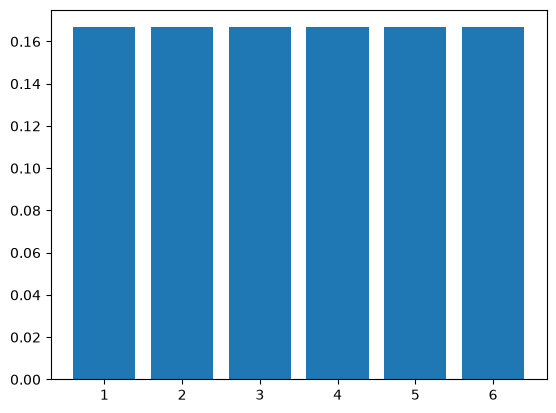

In [11]:
import matplotlib.pyplot as plt

#plot the PMF of a single die
plt.bar(die_outcomes, (1/len(die_outcomes)))


In [12]:
min_outcomes

array([[1, 1, 1, 1, 1, 1],
       [1, 2, 2, 2, 2, 2],
       [1, 2, 3, 3, 3, 3],
       [1, 2, 3, 4, 4, 4],
       [1, 2, 3, 4, 5, 5],
       [1, 2, 3, 4, 5, 6]])

In [13]:
min_outcomes_flat = np.minimum(die_outcomes, die_outcomes.reshape(-1,1)).flatten()   # or .reshape(-1)
min_outcomes_flat

array([1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 1, 2, 3, 3, 3, 3, 1, 2, 3, 4,
       4, 4, 1, 2, 3, 4, 5, 5, 1, 2, 3, 4, 5, 6])

<BarContainer object of 6 artists>

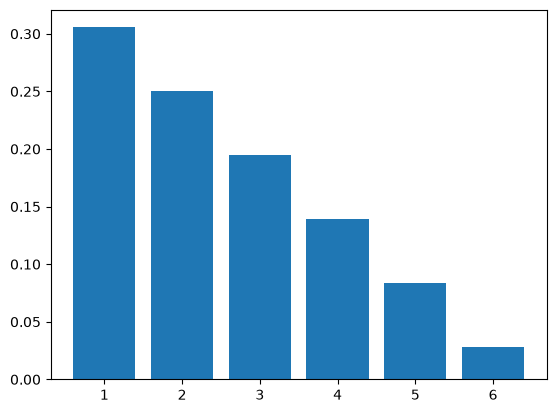

In [14]:
# the PMF of the minimum of two dice
plt.bar(die_outcomes, np.sum(min_outcomes_flat == die_outcomes.reshape(-1,1), axis=1) * (1/len(die_outcomes)**2))

## The dice rolls are **independent**

- Dice rolls are independent, so we can easily calculate what happens when there are 2 or more dice rolled. We can represent this as a **probability tree**, where we string together probability spaces.   
- A **probability tree** is
  1. A set of nodes that correspond to probability spaces
  2. A set of edges that correspond to the outcomes in the probability space at each node 

When our processes are independent, the probabilities of the second die DO NOT CHANGE depending on the first. 

- Event $A$ is **independent** of event $B$ if $p[A \cap B] = p[A] p[B]$, so the probability of their joint occurrence is not determined by whether or not the other event occurred

## Conditional Probability & Expectation
- **Information is about renormalizing to account for a shrinkage of the possibilities**
- The conditional probability of $A$ given $B$ is
$$
p[A|B] = \dfrac{p[A \cap B]}{p[B]}
$$
- We sum the probability that $A$ and $B$ occur together, and then renormalize by $p[B]$ to ensure our probabilties account for the knowledge that $B$ has actually happened


- If we know an event $B$ has occured, we can renormalize the probabilities of different outcomes, and compute the expected value:
$$
\mathbb{E}[X|B] = \sum_{x} x \times p[X=x|B] = \sum_{x} x \times \frac{p[X=x \cap B]}{p[B]}
$$

## Example: base rate fallacy

1. The patient is sick with probability $i$, and healthy with probability $1-i$
2. The test is correct with probability $p$, and incorrect with probability $1-p$
 
Are the patient's health status and the correctness of the test independent? Conditional on getting a positive test, what is the probability the patient is sick?

<img src="./src/bayes_probability_tree.png" width="850px">

>As prevalence goes down (rarer diseases; P(Sick) = small), P(Sick | Test+) is even smaller, meaning most positive tests are coming from people who aren't sick


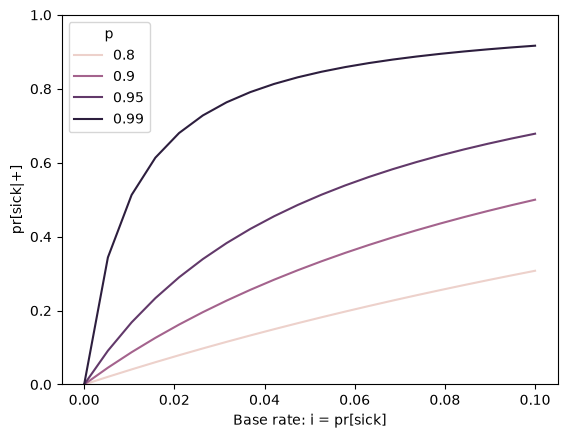

In [15]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

ps = [.8, .9, .95, .99]
is_ = np.linspace(0, .1, 20)

df = pd.DataFrame([{"i": i, "p": p,
    "posterior": (i * p) / (i * p + (1 - i) * (1 - p))}
        for p in ps
        for i in is_
    ])

sns.lineplot(
    data=df,
    x="i",
    y="posterior",
    hue="p",
)

plt.xlabel("Base rate: i = pr[sick]")
plt.ylabel("pr[sick|+]")
plt.ylim(0, 1)
plt.show()

## Example 2

In 1978, Cascella, Schoenberger, and Grayboys asked 60 physicians, students, and house officers at the Harvard Medical school the following question:

>“If a test to detect a disease whose prevalence is 1/1,000 has a false positive rate of 5 per cent, what is the chance that a person found to have a positive result actually has the disease, assuming that you know nothing about the person’s symptoms or signs?”
 


The answers ranged from about 2% to 95%, with 27 out of the 60 Medical School members surveyed answering 95%.

Let’s see what we think the answer should be. First, some background and terminology:

- Prevalence in the population is the percent of people who have the disease. It is also called the base rate of the disease.

- There is a test for the disease that has two possible results for a tested person. A positive result means that according to the test the person has the disease. A negative result means that according to the test the person doesn’t have the disease.
- The test can give a wrong result. The false positive rate is the proportion of positive results among people who don’t have the disease.
- The true positive rate (recall) is the rate of positive results among those who do have the disease. The question doesn’t provide this rate. We will assume, as the people surveyed also did, that the test is good and the true positive rate is 100%.

# Look at a probability tree

<img src="./src/tree_disease_harvard_1.png" width="850px">

## Vaccinations for COVID vs hospitalizations

This is true of vaccinations too. Let's assume most people got vaccinated for COVID (i,.e,. the base rate of vaccination was high). 

Conditioning on hospitalization with COVID: 
- P(vaccinated | hospitalized with COVID) may be high
- even if P(hospitalized with COVID | vaccinated) is low

<img src="./src/Base_rate_fallacy_with_vaccines.svg" width="850px">

> Think about the **extremes**: 
> 
>   if everyone was vaccinated, everyone who had COVID would come from the vaccinated pool so P(vaccinated |hospitalized) = 1
> 
> If no one is sick (incidence of disease was 0), everyone who tests positive would come from the healthy population, so P(sick|+) --> 0

# Conditional probabilities in data

- **Information is about renormalizing to account for a shrinkage of the possibilities**


> Subsetting a df by selecting certain rows where a variable is equal to some value **IS** conditioning on that variable, e.g. `df[df.cough == 1]`
> 
> Looking at proportions of other variable values gives the PMF conditioned on the first variable, e.g. p(disease_group = k | cough=1) for each k, given by:
> `df.groupby('cough').disease_group.value_counts(normalize=True)`

<div class="alert alert-info">
One of the things med students are supposed to learn to do is <b>differential diagnosis</b>: conditioned on particular symptoms, how should a doctor consider the probability of different diseases a patient might have? 

But if the HMS students failed the base rate fallacy question, how are they going to be able to do this conditional updating?</div>

Research actually showed that doctors don't fail this because they can't reason about evidence but because the percentage framing is the hard version of the problem-- if you ask the problem in a way where they have to count up events, rather than think about fractions, they do better. Similarly, working conditional probabilities as a tree, which is what we'll do in the lab, makes for a more intuitive way of solving — counted paths, multiplied along branches. 